In [2]:
from astropy.io import fits
import numpy as np

with fits.open("/home/adfield/ShearNet/unit_tests/third/benchmarking/m/metacal_results.fits") as hdul:
    third_results = hdul[1].data

print("Signal to Noise distribution is:")
print(f"mean: {np.mean(third_results['s2n_noshear'])}, std: {np.std(third_results['s2n_noshear'])}, median: {np.median(third_results['s2n_noshear'])}")

Signal to Noise distribution is:
mean: 31.13000127802811, std: 64.92164119906904, median: 13.404485676558867


In [3]:
"""
Now I know this weirdness only happened AFTER introducing flux from the catalog. Lets plot the catalog's flux distr
"""
from astropy.table import Table
cosmos_cat = Table.read("/home/adfield/ShearNet/cosmos15_superbit2023_phot_shapes_with_sigma.csv", format="csv")

In [9]:
import matplotlib.pyplot as plt

def plot_mag_distribution(flux_raw, xlim=(15, 30), bins=50):
    fig, ax = plt.subplots(figsize=(8, 5))
    
    ax.hist(flux_raw, bins=bins, range=xlim, color='steelblue', edgecolor='white', linewidth=0.4)
    
    ax.set_xlabel('Magnitude', fontsize=13)
    ax.set_ylabel('Count', fontsize=13)
    ax.set_title('Magnitude Distribution', fontsize=14)
    ax.set_xlim(xlim)
    
    ax.axvline(np.median(flux_raw), color='tomato', linestyle='--', linewidth=1.5, label=f'Median = {np.median(flux_raw):.2f}')
    ax.legend(fontsize=11)
    
    plt.tight_layout()
    plt.savefig('mag_distribution.png', dpi=150)
    plt.show()

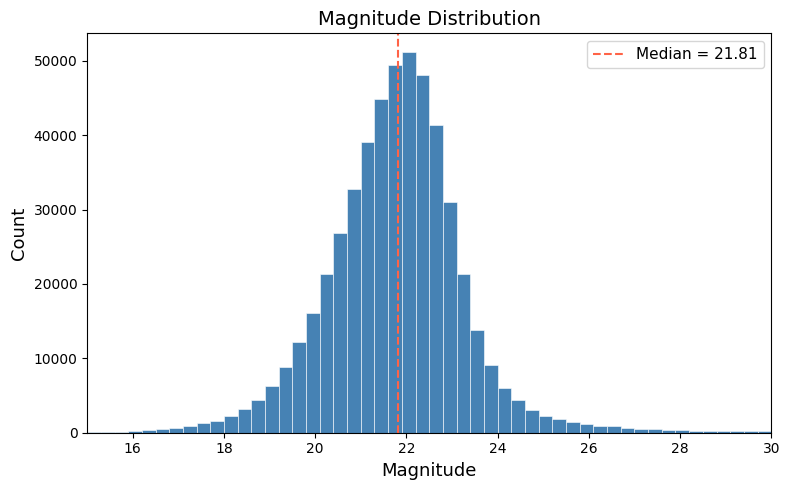

503840 out of 518404


In [16]:
flux_raw = np.array(cosmos_cat['crates_b'], dtype=np.float64) * 300 * 36 / 0.343
mag_raw = np.log10(flux_raw) * -2.5 + 30.0
plot_mag_distribution(mag_raw)
flux_raw_filtered = flux_raw[flux_raw >= 100]
print(f"{len(flux_raw_filtered)} out of {len(flux_raw)}")